In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Eco_Vision

/content/drive/MyDrive/Eco_Vision


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
DATASET_PATH = "/content/drive/MyDrive/Eco_Vision/Garbage_classification"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

In [6]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print("Classes:", train_data.class_indices)

Found 2805 images belonging to 7 classes.
Found 700 images belonging to 7 classes.
Classes: {'battery': 0, 'cardboard': 1, 'glass': 2, 'metal': 3, 'paper': 4, 'plastic': 5, 'trash': 6}


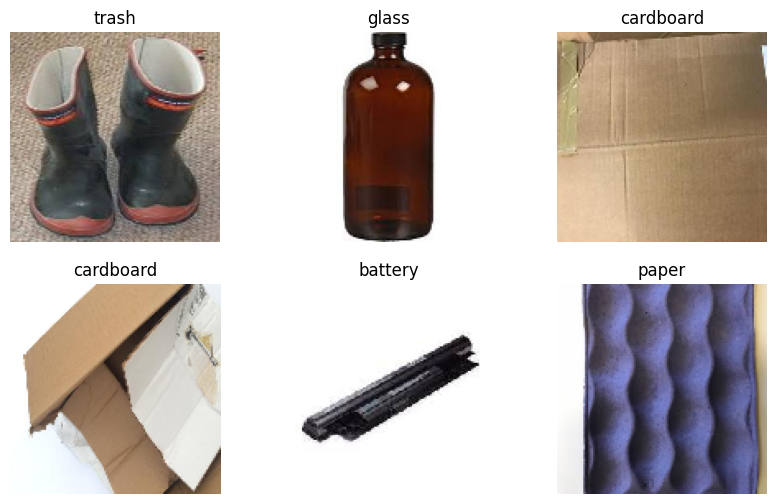

In [7]:
images, labels = next(train_data)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[np.argmax(labels[i])])
    plt.axis("off")
plt.show()

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,223 (28.20 MB)

 Trainable params: 7,393,223 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 793s 9s/step - accuracy: 0.1893 - loss: 2.4369 - val_accuracy: 0.3971 - val_loss: 1.6692
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.3837 - loss: 1.5898 - val_accuracy: 0.5014 - val_loss: 1.4687
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.4775 - loss: 1.4305 - val_accuracy: 0.4957 - val_loss: 1.4382
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5209 - loss: 1.2969 - val_accuracy: 0.4943 - val_loss: 1.3938
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5884 - loss: 1.1255 - val_accuracy: 0.5271 - val_loss: 1.2826
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6574 - loss: 0.9373 - val_accuracy: 0.5414 - val_loss: 1.3507
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6852 - loss: 0.8396 - val_accuracy: 0.5543 - val_loss: 1.3141
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7270 - loss: 0.7336 - val_accuracy: 0.5471 - val_los

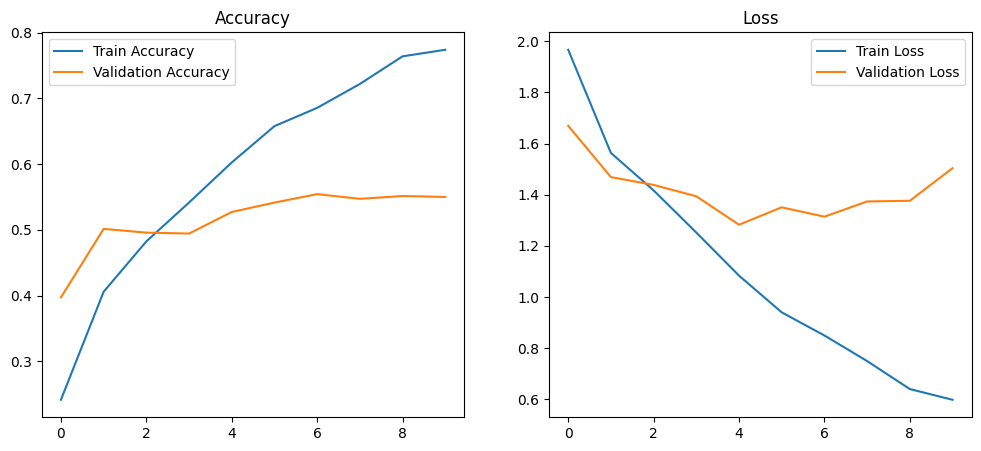

In [10]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 347ms/step - accuracy: 0.5552 - loss: 1.3988
Test Accuracy: 0.550000011920929


22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 309ms/step


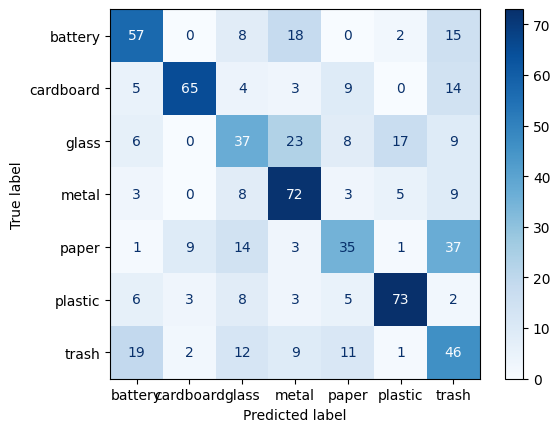

In [12]:
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=test_data.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [13]:
MODEL_PATH = "/content/drive/MyDrive/Eco_Vision/ecovision_cnn_model.keras"
model.save(MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: /content/drive/MyDrive/Eco_Vision/ecovision_cnn_model.keras


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2805 images belonging to 7 classes.
Found 700 images belonging to 7 classes.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_v2 = Sequential()

model_v2.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Conv2D(64,(3,3),activation='relu'))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Conv2D(128,(3,3),activation='relu'))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Flatten())

model_v2.add(Dense(256,activation='relu'))
model_v2.add(Dropout(0.5))

model_v2.add(Dense(train_data.num_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
history_v2 = model_v2.fit(
    train_data,
    validation_data=validation_data,
    epochs=15,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.2182 - loss: 1.9692 - val_accuracy: 0.3971 - val_loss: 1.6278
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.4521 - loss: 1.4821 - val_accuracy: 0.4114 - val_loss: 1.5854
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.4699 - loss: 1.4303 - val_accuracy: 0.4557 - val_loss: 1.4066
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5399 - loss: 1.2953 - val_accuracy: 0.4743 - val_loss: 1.3780
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5481 - loss: 1.2193 - val_accuracy: 0.5529 - val_loss: 1.2724
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.5864 - loss: 1.1796 - val_accuracy: 0.5657 - val_loss: 1.2223
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6101 - loss: 1.1008 - val_accuracy: 0.5643 - val_loss: 1.1696
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6030 - loss: 1.1239 - val_accuracy: 0.5971 - v

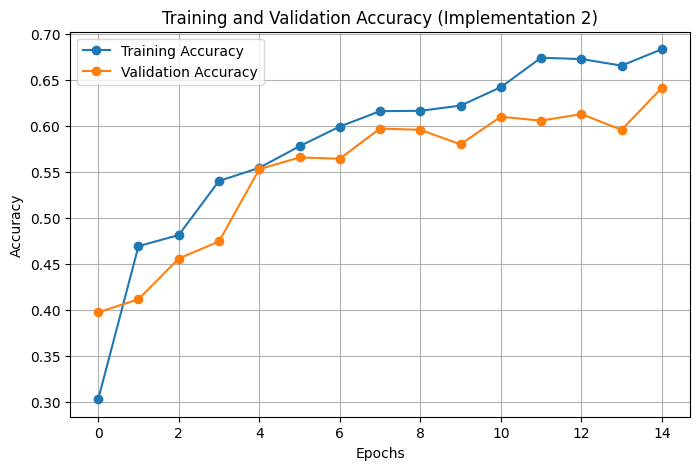

In [21]:
# Plot training & validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy (Implementation 2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

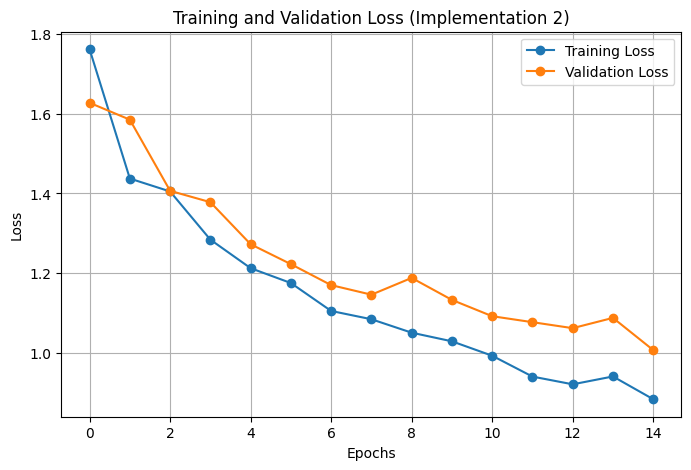

In [22]:
# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['loss'], label='Training Loss', marker='o')
plt.plot(history_v2.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss (Implementation 2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 743ms/step


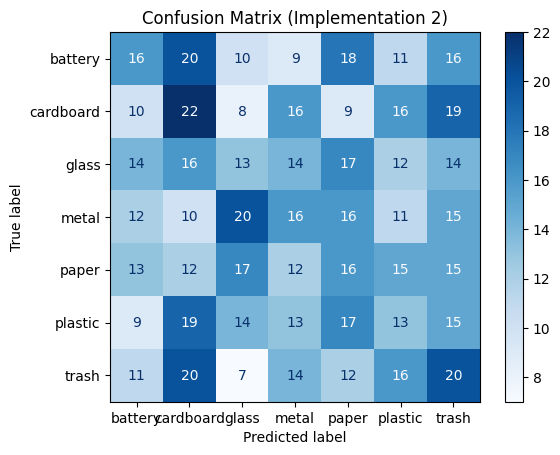

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
y_true = validation_data.classes
y_pred = np.argmax(model_v2.predict(validation_data), axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=validation_data.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Implementation 2)")
plt.show()

In [24]:
model_v2.save("/content/drive/MyDrive/Eco_Vision/model_v2.h5")